# Loading Master Table Data

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates

master_df = pd.read_csv('D:/Varanasi_Air_Quality/data/processed/master_clean.csv',
                         parse_dates=['Timestamp'])

print(" Master data loaded")
print(f"Total rows    : {len(master_df):,}")
print(f"Total columns : {master_df.shape[1]}")
print(f"Date range    : {master_df['Timestamp'].min()} → {master_df['Timestamp'].max()}")
print(f"Stations      : {master_df['station'].unique().tolist()}")

 Master data loaded
Total rows    : 35,040
Total columns : 29
Date range    : 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Stations      : ['ardhali_bazar', 'bhelupur', 'bhu_iesd', 'maldahiya']


# PM2.5 Diurnal Curve - All 4 Stations
### Shows how PM2.5 changes across 24 hours on average


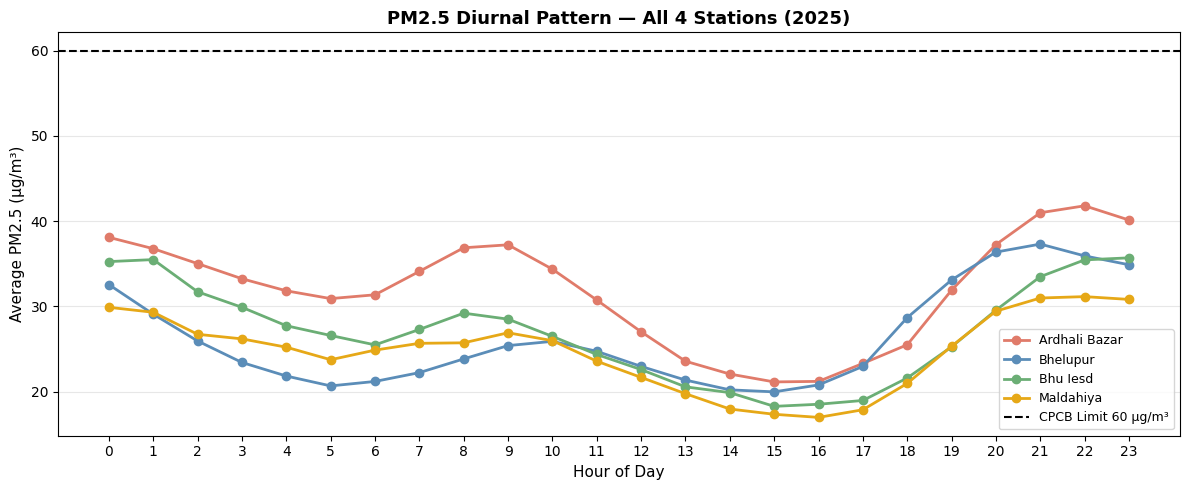

 PM2.5 diurnal chart


In [38]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/diurnal', exist_ok=True)

colors = {
    'bhelupur'     : '#5B8DB8',
    'ardhali_bazar': '#E07B6A',
    'bhu_iesd'     : '#6BAE75',
    'maldahiya'    : '#E6A817'
}

fig, ax = plt.subplots(figsize=(12, 5))

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    hourly_avg = df_s.groupby('hour')['PM2.5 (µg/m³)'].mean()
    ax.plot(hourly_avg.index, hourly_avg.values,
            color=colors[station],
            marker='o',
            linewidth=2,
            label=station.replace('_',' ').title())

ax.axhline(y=60, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 60 µg/m³')

ax.set_xticks(range(0, 24))
ax.set_title('PM2.5 Diurnal Pattern — All 4 Stations (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average PM2.5 (µg/m³)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/diurnal/pm25_diurnal_all_stations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" PM2.5 diurnal chart")

# PM2.5 Seasonal Diurnal Pattern 

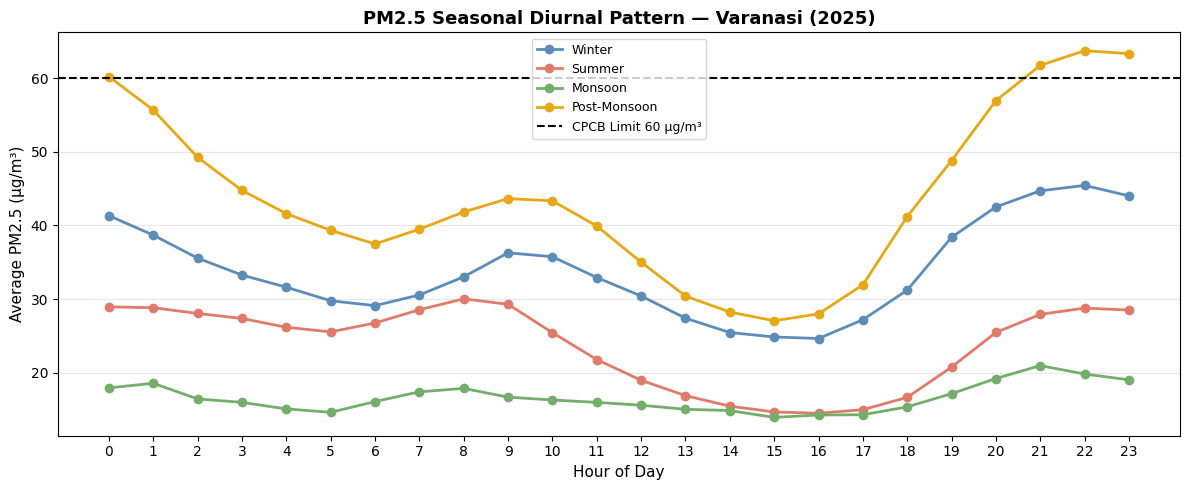

In [39]:
season_colors = {
    'Winter'      : '#5B8DB8',
    'Summer'      : '#E07B6A',
    'Monsoon'     : "#73AE6B",
    'Post-Monsoon': '#E6A817'
}

fig, ax = plt.subplots(figsize=(12, 5))

for season in ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']:
    df_s = master_df[master_df['season'] == season]
    hourly_avg = df_s.groupby('hour')['PM2.5 (µg/m³)'].mean()
    ax.plot(hourly_avg.index, hourly_avg.values,
            color=season_colors[season],
            marker='o',
            linewidth=2,
            label=season)

ax.axhline(y=60, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 60 µg/m³')
ax.set_xticks(range(0, 24))
ax.set_title('PM2.5 Seasonal Diurnal Pattern — Varanasi (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average PM2.5 (µg/m³)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/diurnal/pm25_seasonal_diurnal.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Month x Hour Heatmap - PM2.5
## Signature visual of the project

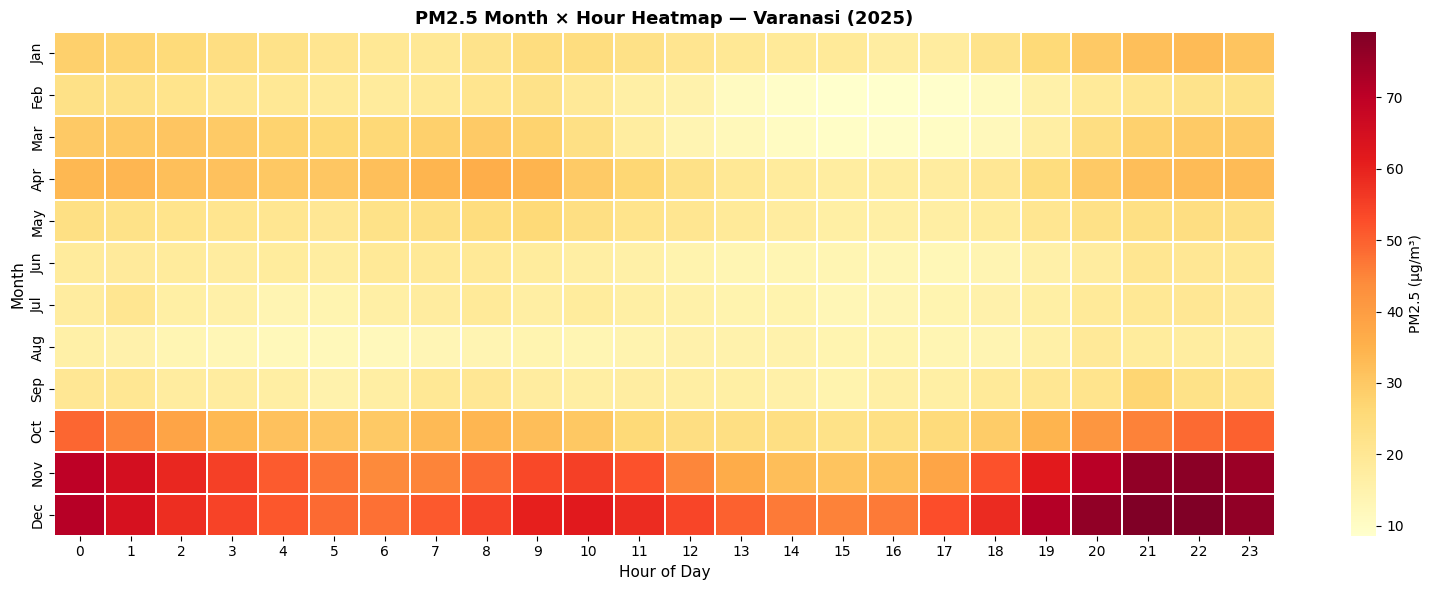

PM2.5 heatmap


In [40]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Create pivot table - rows=month, columns=hour, values=avg PM2.5
pivot_pm25 = master_df.pivot_table(
    values='PM2.5 (µg/m³)',
    index='month',
    columns='hour',
    aggfunc='mean'
)
pivot_pm25.index = month_names

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_pm25,
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.3,
            cbar_kws={'label': 'PM2.5 (µg/m³)'})
ax.set_title('PM2.5 Month × Hour Heatmap — Varanasi (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section4_seasonal/heatmap_pm25.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("PM2.5 heatmap")

#  Month x Hour Heatmap - Ozone
#### Opposite pattern to PM2.5 - peaks at noon

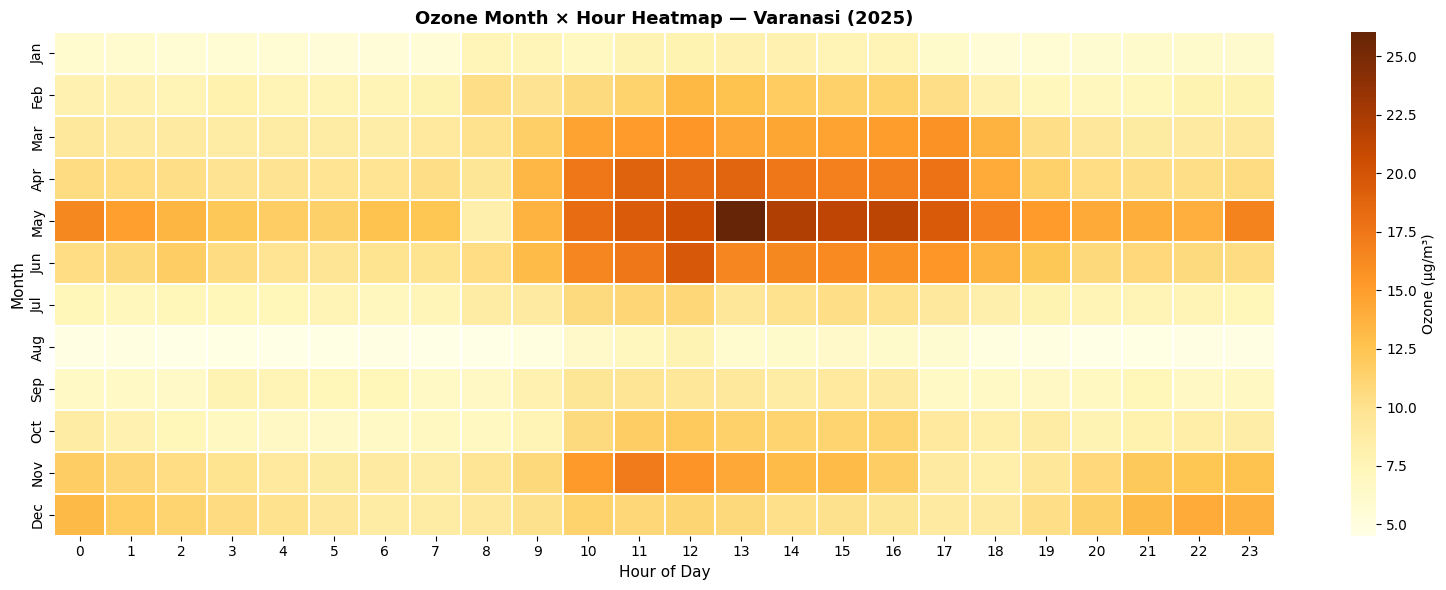

Ozone heatmap


In [41]:
pivot_ozone = master_df.pivot_table(
    values='Ozone (µg/m³)',
    index='month',
    columns='hour',
    aggfunc='mean'
)
pivot_ozone.index = month_names

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_ozone,
            cmap='YlOrBr',
            ax=ax,
            linewidths=0.3,
            cbar_kws={'label': 'Ozone (µg/m³)'})
ax.set_title('Ozone Month × Hour Heatmap — Varanasi (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section4_seasonal/heatmap_ozone.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Ozone heatmap")

# 8 Hour Rolling Ozone - CPCB Standard

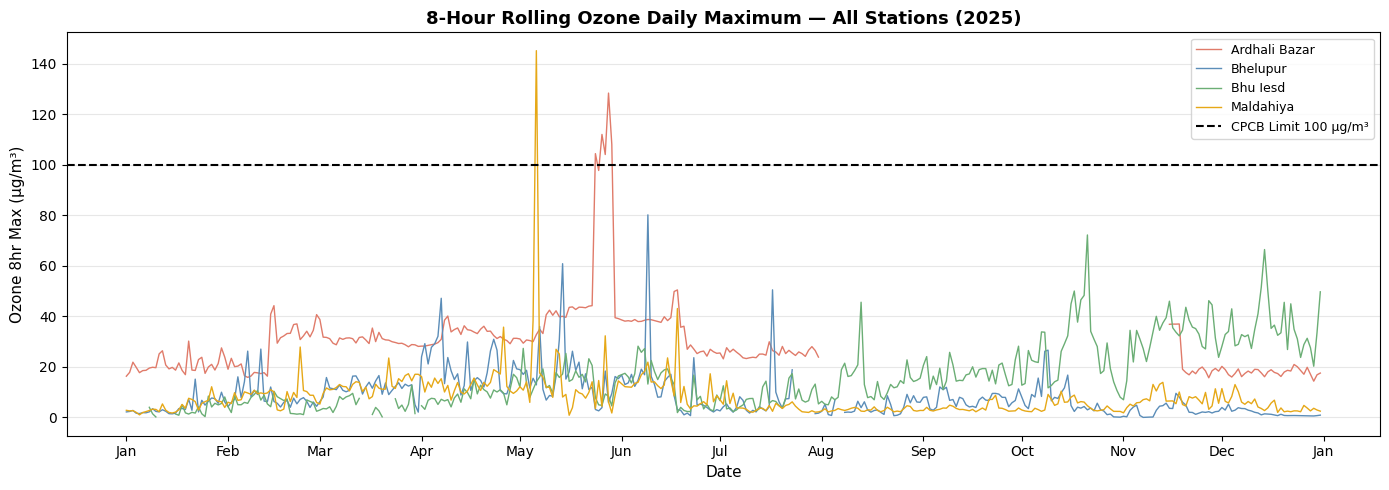

8hr rolling Ozone chart


In [42]:
fig, ax = plt.subplots(figsize=(14, 5))

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station].copy()
    df_s = df_s.sort_values('Timestamp')

    # Calculate 8 hour rolling average
    df_s['ozone_8hr'] = df_s['Ozone (µg/m³)'].rolling(window=8).mean()

    # Daily maximum of 8hr rolling average
    daily_max = df_s.groupby(df_s['Timestamp'].dt.date)['ozone_8hr'].max()

    ax.plot(daily_max.index, daily_max.values,
            color=colors[station],
            linewidth=1,
            label=station.replace('_',' ').title())

ax.axhline(y=100, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 100 µg/m³')
ax.set_title('8-Hour Rolling Ozone Daily Maximum — All Stations (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Ozone 8hr Max (µg/m³)', fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section4_seasonal/ozone_8hr_rolling.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("8hr rolling Ozone chart")

# Station Ranking
## Which station has worst PM2.5, PM10, AQI

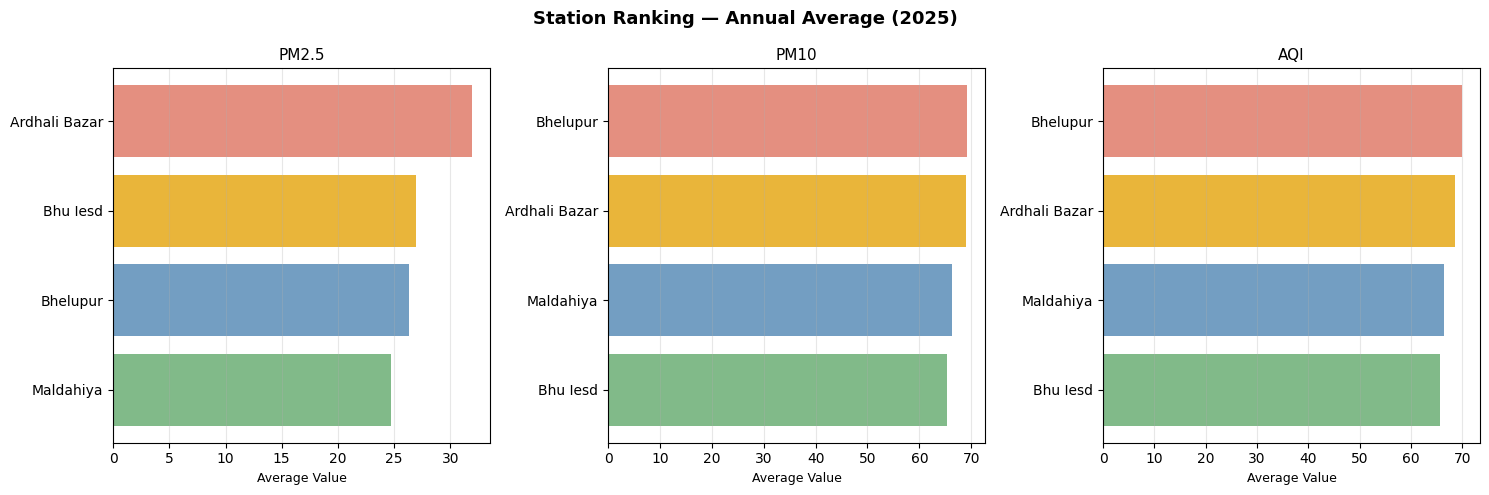

In [43]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section5_spatial', exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Station Ranking — Annual Average (2025)',
             fontsize=13, fontweight='bold')

params_rank = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'AQI']
titles = ['PM2.5', 'PM10', 'AQI']

for i, param in enumerate(params_rank):
    station_avg = master_df.groupby('station')[param].mean().sort_values(ascending=True)
    station_labels = [s.replace('_',' ').title() for s in station_avg.index]

    axes[i].barh(station_labels, station_avg.values,
                 color=['#6BAE75','#5B8DB8','#E6A817','#E07B6A'],
                 alpha=0.85)
    axes[i].set_title(titles[i], fontsize=11)
    axes[i].set_xlabel('Average Value', fontsize=9)
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section5_spatial/station_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()


# AQI Category Distribution Per Station
## What % of year each station spent in each AQI category

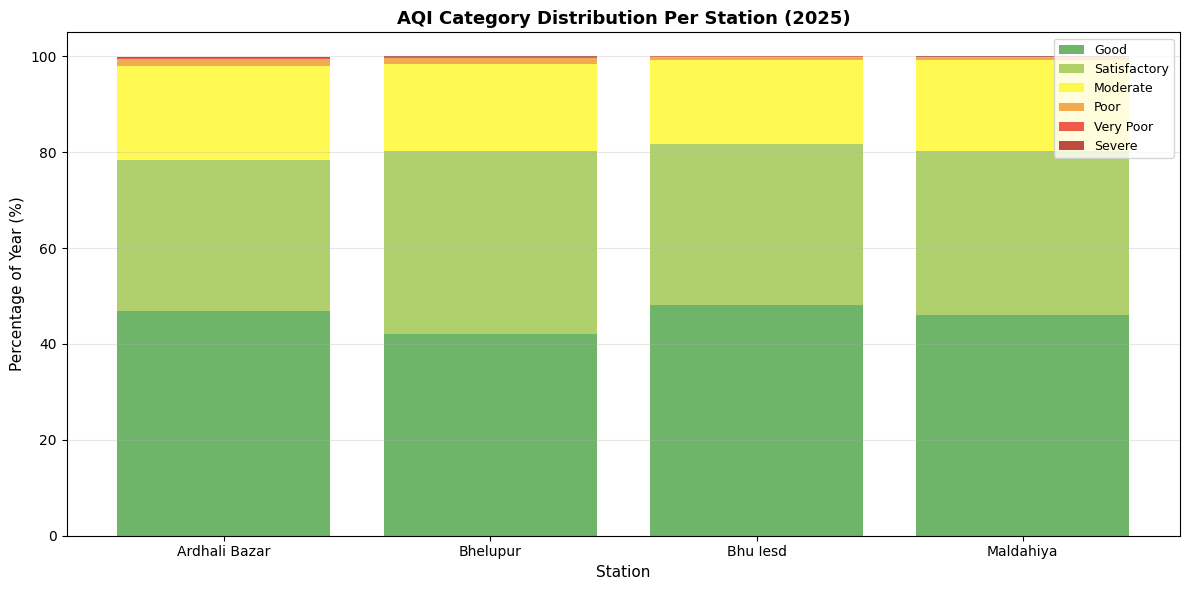

In [44]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section5_spatial', exist_ok=True)

aqi_colors = {
    'Good'        : '#55A84F',
    'Satisfactory': '#A3C853',
    'Moderate'    : '#FFF833',
    'Poor'        : '#F29C33',
    'Very Poor'   : '#E93F33',
    'Severe'      : '#AF2D24'
}

category_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']

fig, ax = plt.subplots(figsize=(12, 6))

stations = master_df['station'].unique()
bar_bottoms = np.zeros(len(stations))
station_labels = [s.replace('_',' ').title() for s in stations]

for category in category_order:
    values = []
    for station in stations:
        df_s = master_df[master_df['station'] == station]
        pct = (df_s['AQI_Category'] == category).sum() / len(df_s) * 100
        values.append(pct)

    ax.bar(station_labels, values,
           bottom=bar_bottoms,
           color=aqi_colors[category],
           label=category,
           alpha=0.85)
    bar_bottoms += np.array(values)

ax.set_title('AQI Category Distribution Per Station (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Station', fontsize=11)
ax.set_ylabel('Percentage of Year (%)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section5_spatial/aqi_category_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Monthly PM2.5 Comparison All 4 Stations

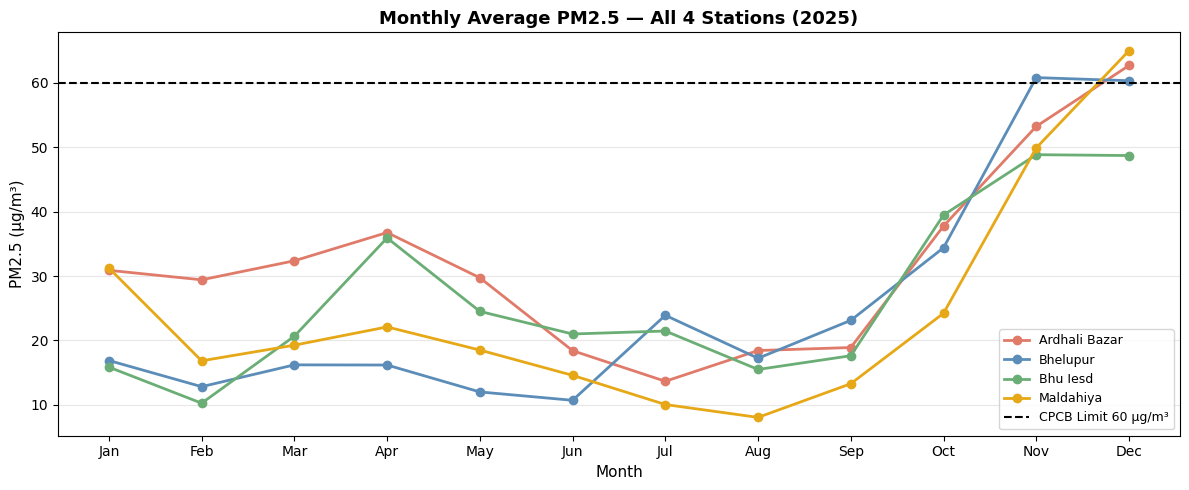

In [45]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))

for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    monthly_avg = df_s.groupby('month')['PM2.5 (µg/m³)'].mean()
    ax.plot(monthly_avg.index, monthly_avg.values,
            color=colors[station],
            marker='o',
            linewidth=2,
            label=station.replace('_',' ').title())

ax.axhline(y=60, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 60 µg/m³')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Monthly Average PM2.5 — All 4 Stations (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section5_spatial/monthly_pm25_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Daily AQI Time Series Full Year


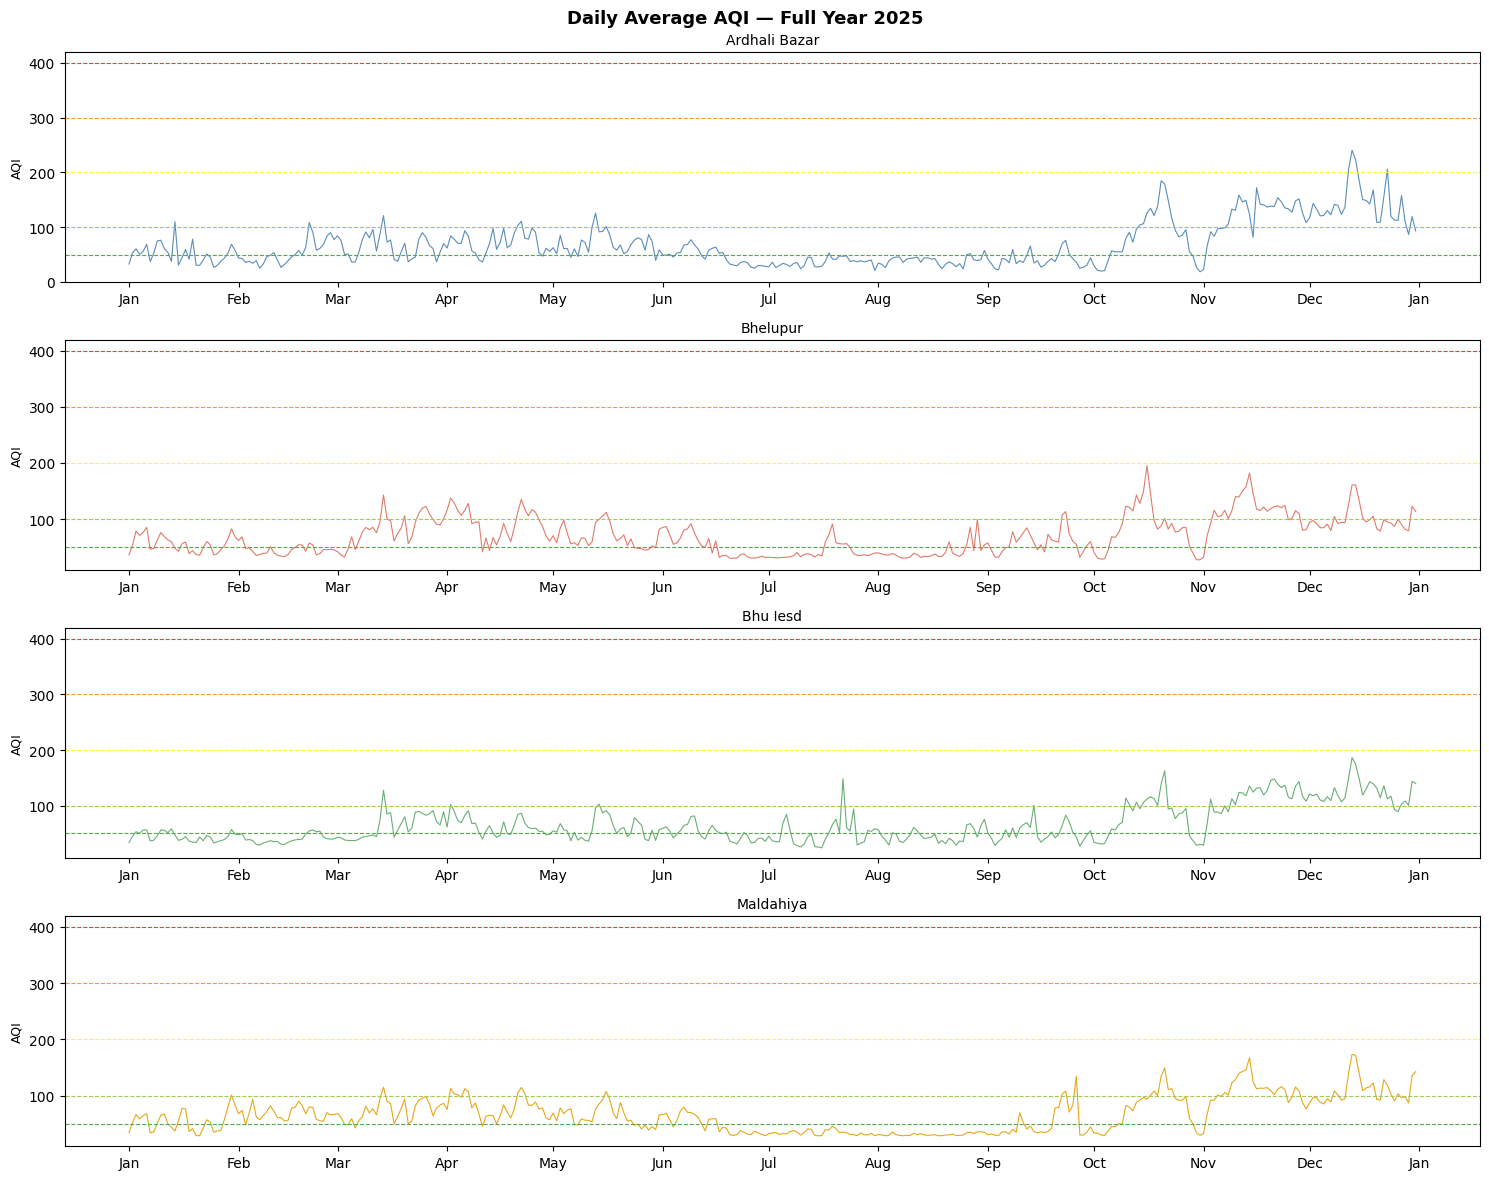

In [47]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section6_aqi', exist_ok=True)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('Daily Average AQI — Full Year 2025',
             fontsize=13, fontweight='bold')

# AQI category boundary lines
aqi_lines = {
    'Good (50)'         : (50,  '#55A84F'),
    'Satisfactory (100)': (100, '#A3C853'),
    'Moderate (200)'    : (200, '#FFF833'),
    'Poor (300)'        : (300, '#F29C33'),
    'Very Poor (400)'   : (400, '#E93F33'),
}

for i, station in enumerate(master_df['station'].unique()):
    df_s = master_df[master_df['station'] == station].copy()
    df_s['date'] = df_s['Timestamp'].dt.date
    daily_aqi = df_s.groupby('date')['AQI'].mean()

    axes[i].plot(daily_aqi.index, daily_aqi.values,
                 color=list(colors.values())[i],
                 linewidth=0.8)

    for label, (val, col) in aqi_lines.items():
        axes[i].axhline(y=val, color=col,
                        linestyle='--', linewidth=0.8)

    axes[i].set_title(station.replace('_',' ').title(), fontsize=10)
    axes[i].set_ylabel('AQI', fontsize=9)
    axes[i].xaxis.set_major_locator(mdates.MonthLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section6_aqi/daily_aqi_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()

# AQI Category Pie Charts Per Station


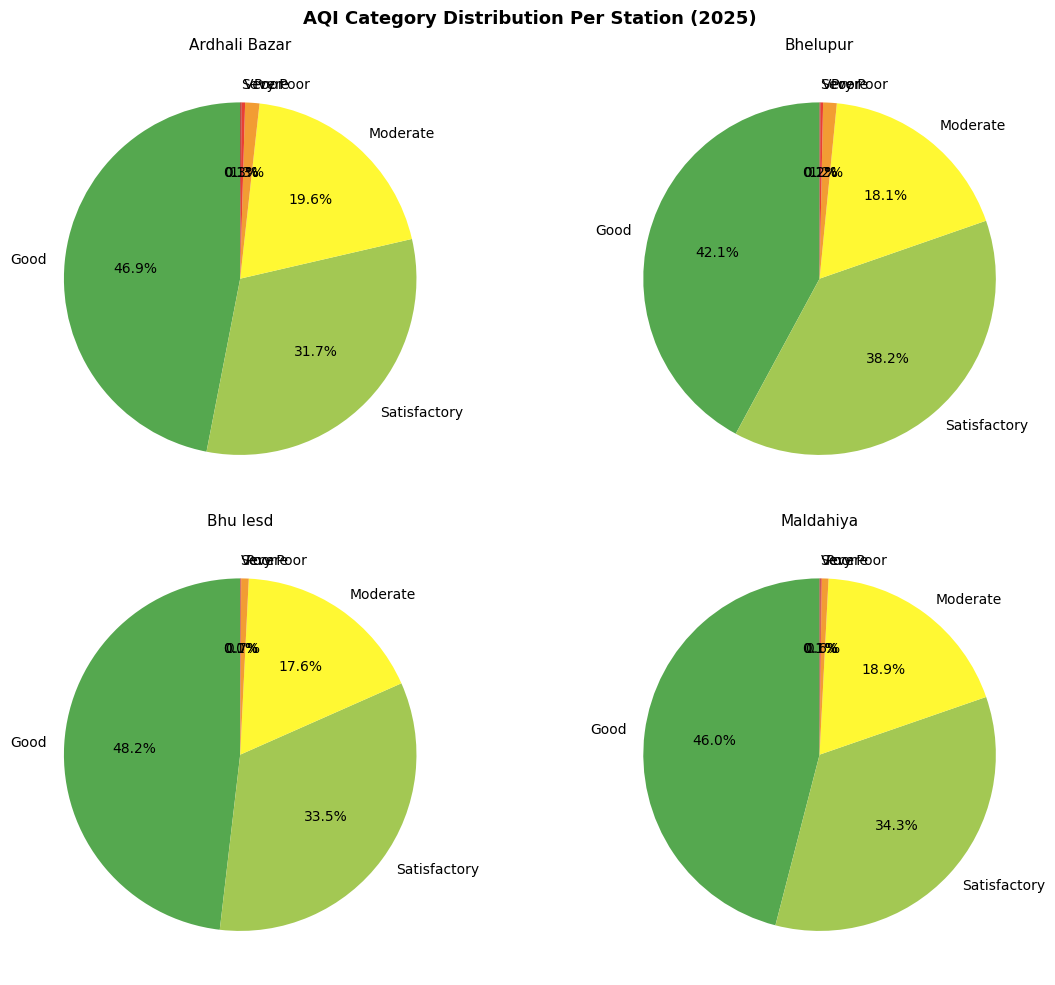

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('AQI Category Distribution Per Station (2025)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

category_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
pie_colors = ['#55A84F','#A3C853','#FFF833','#F29C33','#E93F33','#AF2D24']

for i, station in enumerate(master_df['station'].unique()):
    df_s = master_df[master_df['station'] == station]
    counts = df_s['AQI_Category'].value_counts()

    # Reorder categories
    counts = counts.reindex(category_order).fillna(0)

    # Remove zero categories
    counts = counts[counts > 0]

    axes[i].pie(counts.values,
                labels=counts.index,
                colors=pie_colors[:len(counts)],
                autopct='%1.1f%%',
                startangle=90)
    axes[i].set_title(station.replace('_',' ').title(), fontsize=11)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section6_aqi/aqi_pie_charts.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Which Pollutant Drives AQI Most
## Count how many hours each pollutant sub-index was maximum


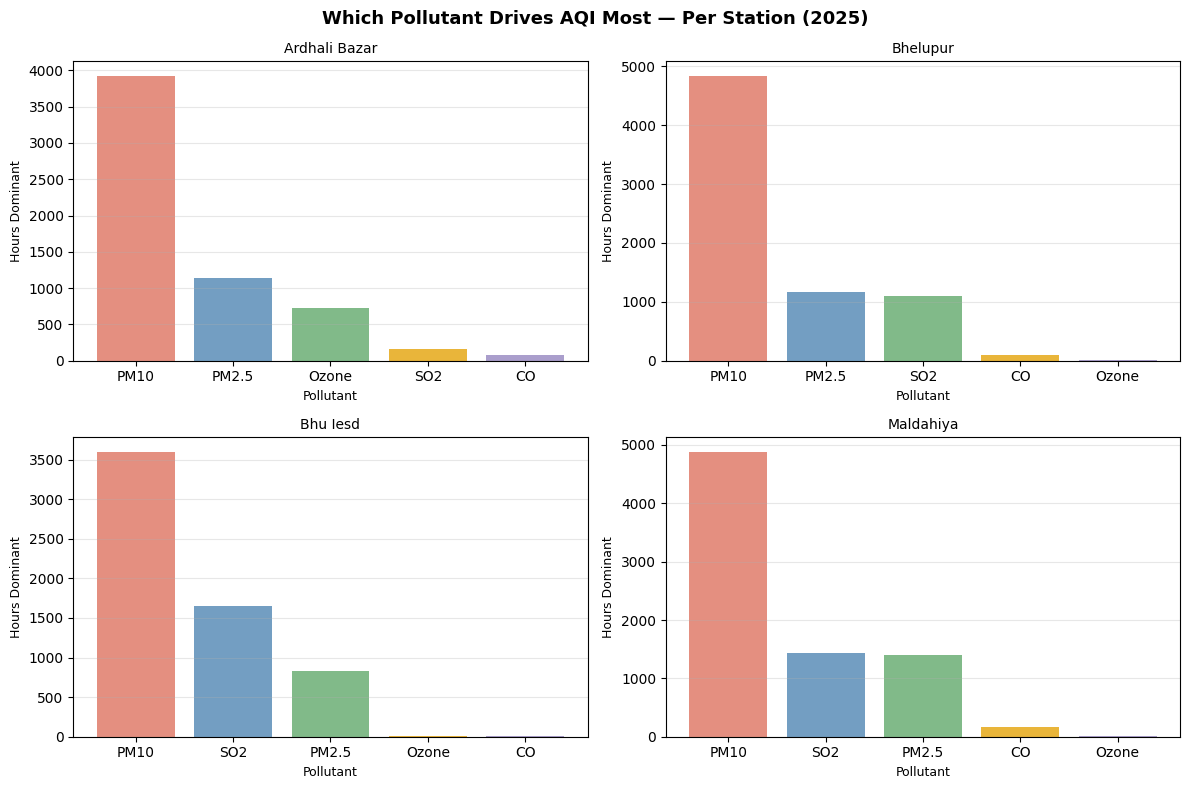

In [49]:
si_cols = ['SI_PM2.5', 'SI_PM10', 'SI_SO2', 'SI_CO', 'SI_Ozone']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Which Pollutant Drives AQI Most — Per Station (2025)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, station in enumerate(master_df['station'].unique()):
    df_s = master_df[master_df['station'] == station][si_cols].dropna()

    # Find which sub-index column is maximum for each row
    dominant = df_s.idxmax(axis=1)
    counts = dominant.value_counts()

    # Clean labels
    counts.index = [c.replace('SI_','') for c in counts.index]

    axes[i].bar(counts.index, counts.values,
                color=['#E07B6A','#5B8DB8','#6BAE75','#E6A817','#9B8DC4'],
                alpha=0.85)
    axes[i].set_title(station.replace('_',' ').title(), fontsize=10)
    axes[i].set_xlabel('Pollutant', fontsize=9)
    axes[i].set_ylabel('Hours Dominant', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section6_aqi/aqi_dominant_pollutant.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Health Risk Hours Per Month
## Count hours where PM2.5 exceeded CPCB safe limit of 60 µg/m³


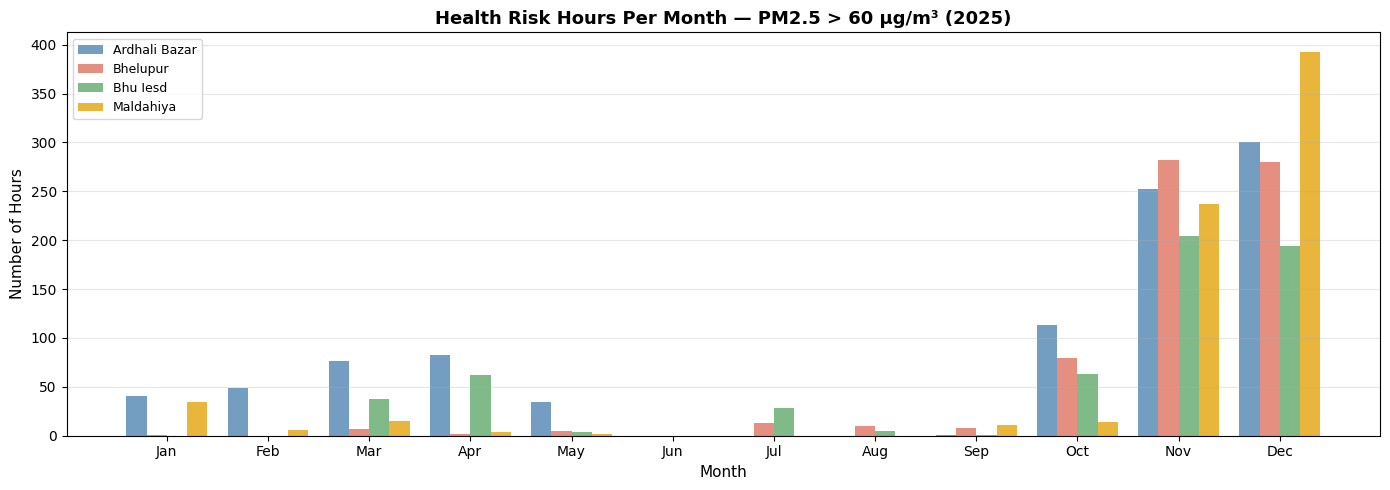

In [52]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section7_health', exist_ok=True)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))

stations = master_df['station'].unique()
n = len(stations)
bar_width = 0.2
x = np.arange(1, 13)

for i, station in enumerate(stations):
    df_s = master_df[master_df['station'] == station]
    monthly_risk = df_s.groupby('month')['PM2.5 (µg/m³)'].apply(
        lambda x: (x > 60).sum()
    )
    ax.bar(x + i * bar_width,
           monthly_risk.values,
           width=bar_width,
           color=list(colors.values())[i],
           label=station.replace('_',' ').title(),
           alpha=0.85)

ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(month_names)
ax.set_title('Health Risk Hours Per Month — PM2.5 > 60 µg/m³ (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Hours', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section7_health/health_risk_hours_monthly.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Health Risk Hours Per Station
## What % of entire year each station had dangerous PM2.5


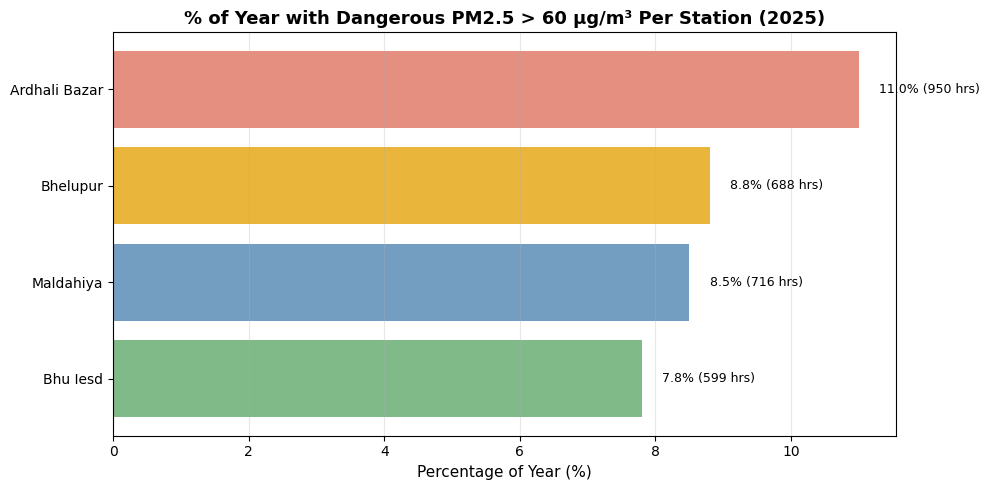

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

station_risk = []
for station in master_df['station'].unique():
    df_s = master_df[master_df['station'] == station]
    total_hours  = df_s['PM2.5 (µg/m³)'].dropna().count()
    risk_hours   = (df_s['PM2.5 (µg/m³)'] > 60).sum()
    risk_pct     = round(risk_hours / total_hours * 100, 1)
    station_risk.append({
        'station' : station.replace('_',' ').title(),
        'risk_pct': risk_pct,
        'hours'   : risk_hours
    })

risk_df = pd.DataFrame(station_risk).sort_values('risk_pct', ascending=True)

bars = ax.barh(risk_df['station'], risk_df['risk_pct'],
               color=['#6BAE75','#5B8DB8','#E6A817','#E07B6A'],
               alpha=0.85)

# Add value labels on bars
for bar, pct, hrs in zip(bars, risk_df['risk_pct'], risk_df['hours']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}% ({hrs} hrs)',
            va='center', fontsize=9)

ax.set_title('% of Year with Dangerous PM2.5 > 60 µg/m³ Per Station (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of Year (%)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section7_health/health_risk_per_station.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Top 10 Worst Days
## Finding 10 days with highest AQI across all stations


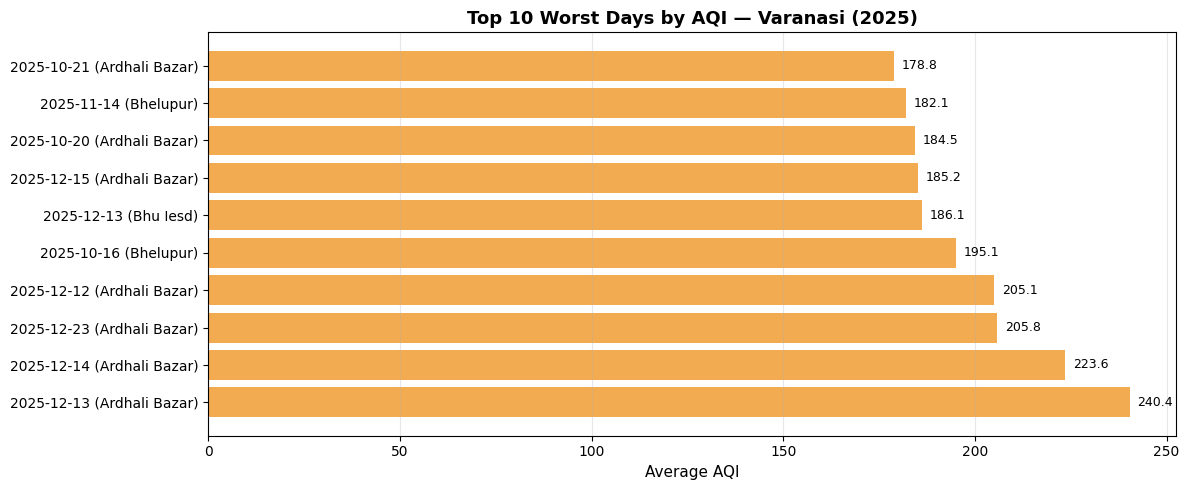


Top 10 Worst Days:
      Date       Station  Avg_AQI
2025-12-13 ardhali_bazar    240.4
2025-12-14 ardhali_bazar    223.6
2025-12-23 ardhali_bazar    205.8
2025-12-12 ardhali_bazar    205.1
2025-10-16      bhelupur    195.1
2025-12-13      bhu_iesd    186.1
2025-12-15 ardhali_bazar    185.2
2025-10-20 ardhali_bazar    184.5
2025-11-14      bhelupur    182.1
2025-10-21 ardhali_bazar    178.8


In [54]:
master_df['date'] = master_df['Timestamp'].dt.date

daily_aqi = master_df.groupby(['date','station'])['AQI'].mean().reset_index()
daily_aqi.columns = ['Date','Station','Avg_AQI']
daily_aqi = daily_aqi.sort_values('Avg_AQI', ascending=False).head(10)
daily_aqi['Avg_AQI'] = daily_aqi['Avg_AQI'].round(1)

fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = ['#AF2D24' if aqi > 400
              else '#E93F33' if aqi > 300
              else '#F29C33'
              for aqi in daily_aqi['Avg_AQI']]

bars = ax.barh(
    [f"{row['Date']} ({row['Station'].replace('_',' ').title()})"
     for _, row in daily_aqi.iterrows()],
    daily_aqi['Avg_AQI'],
    color=bar_colors,
    alpha=0.85
)

for bar, val in zip(bars, daily_aqi['Avg_AQI']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_title('Top 10 Worst Days by AQI — Varanasi (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average AQI', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section7_health/top10_worst_days.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Worst Days:")
print(daily_aqi.to_string(index=False))

# Correlation Matrix Heatmap


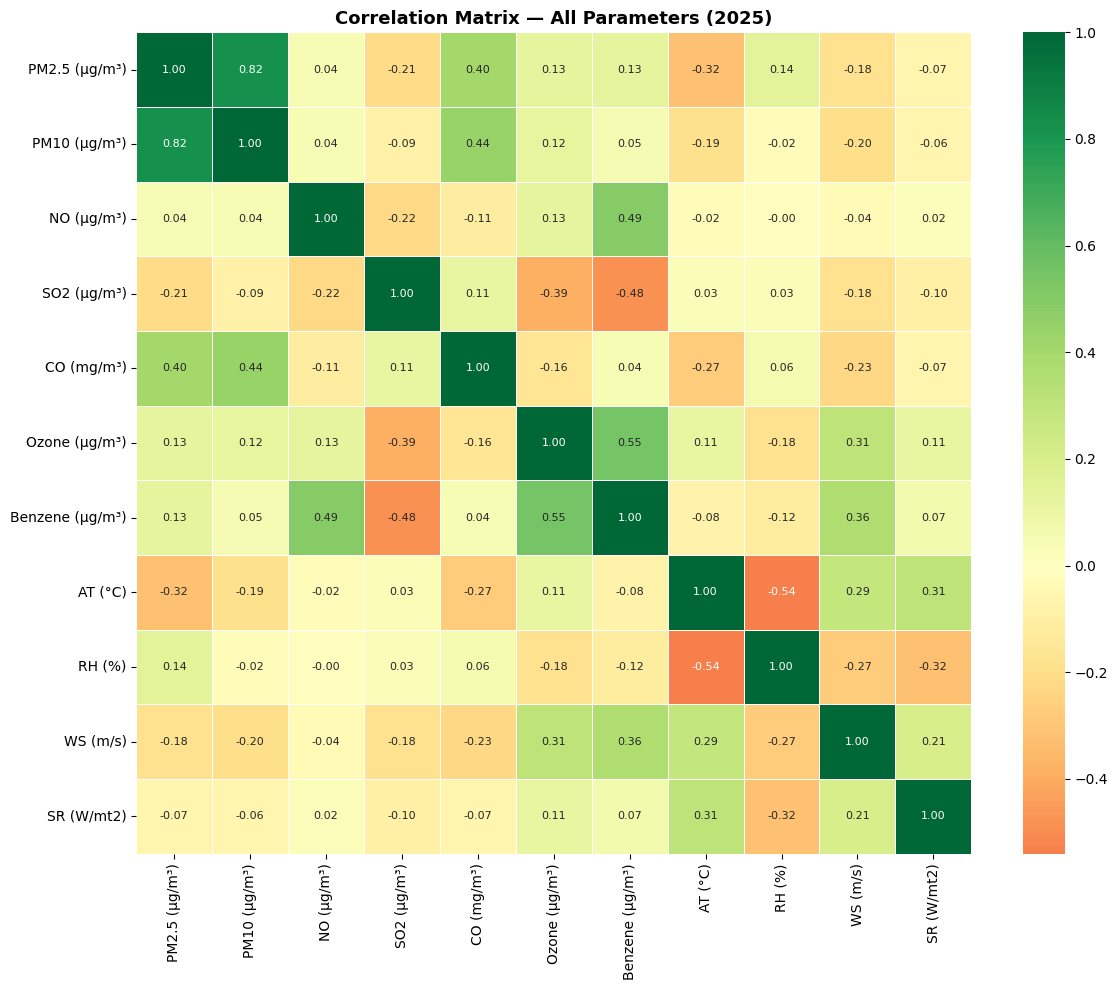

In [55]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section9_correlation', exist_ok=True)

corr_params = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
               'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
               'Benzene (µg/m³)', 'AT (°C)', 'RH (%)',
               'WS (m/s)', 'SR (W/mt2)']

corr_matrix = master_df[corr_params].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — All Parameters (2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section9_correlation/correlation_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()


# Scatter Plots
## PM2.5 vs Wind Speed and Ozone vs Solar Radiation


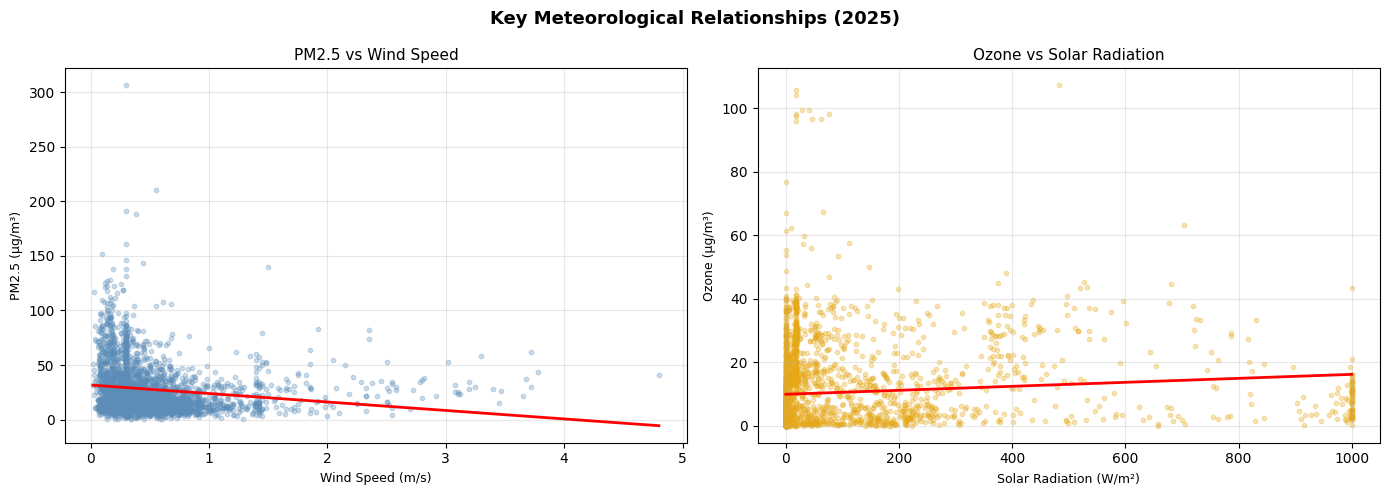

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Key Meteorological Relationships (2025)',
             fontsize=13, fontweight='bold')

# Plot 1 - PM2.5 vs Wind Speed
sample = master_df[['PM2.5 (µg/m³)','WS (m/s)']].dropna().sample(3000)
axes[0].scatter(sample['WS (m/s)'], sample['PM2.5 (µg/m³)'],
                alpha=0.3, color='#5B8DB8', s=10)

# Add regression line
z = np.polyfit(sample['WS (m/s)'], sample['PM2.5 (µg/m³)'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['WS (m/s)'].min(), sample['WS (m/s)'].max(), 100)
axes[0].plot(x_line, p(x_line), color='red', linewidth=2)
axes[0].set_title('PM2.5 vs Wind Speed', fontsize=11)
axes[0].set_xlabel('Wind Speed (m/s)', fontsize=9)
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
axes[0].grid(alpha=0.3)

# Plot 2 - Ozone vs Solar Radiation
sample2 = master_df[['Ozone (µg/m³)','SR (W/mt2)']].dropna().sample(3000)
axes[1].scatter(sample2['SR (W/mt2)'], sample2['Ozone (µg/m³)'],
                alpha=0.3, color='#E6A817', s=10)

z2 = np.polyfit(sample2['SR (W/mt2)'], sample2['Ozone (µg/m³)'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(sample2['SR (W/mt2)'].min(), sample2['SR (W/mt2)'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='red', linewidth=2)
axes[1].set_title('Ozone vs Solar Radiation', fontsize=11)
axes[1].set_xlabel('Solar Radiation (W/m²)', fontsize=9)
axes[1].set_ylabel('Ozone (µg/m³)', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section9_correlation/scatter_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Wind Speed Impact on PM2.5
## Box plots of PM2.5 grouped by wind speed category


C:\Users\pc\AppData\Local\Temp\ipykernel_13496\2698593656.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_wind,


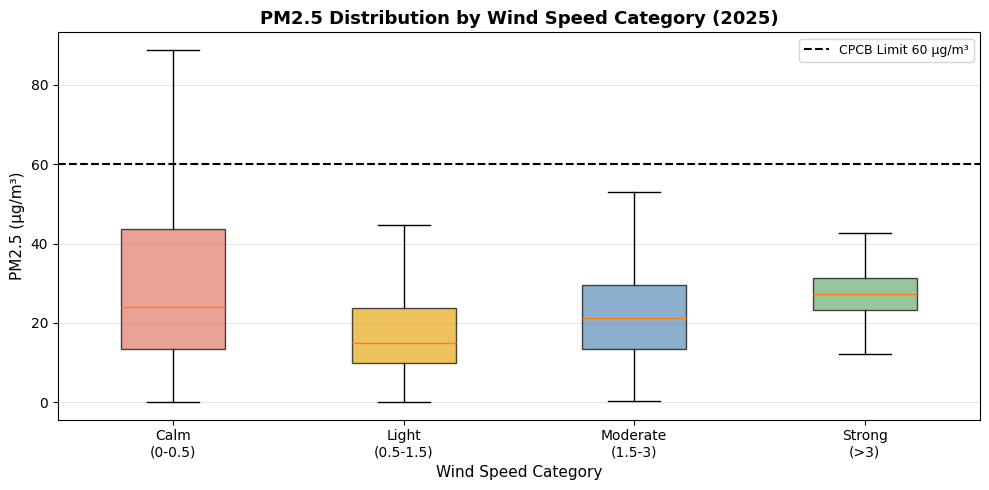

In [57]:
os.makedirs('D:/varanasi_air_quality/outputs/charts/section10_meteo', exist_ok=True)

# Create wind speed categories
master_df['wind_cat'] = pd.cut(
    master_df['WS (m/s)'],
    bins   = [0, 0.5, 1.5, 3, 100],
    labels = ['Calm\n(0-0.5)', 'Light\n(0.5-1.5)',
              'Moderate\n(1.5-3)', 'Strong\n(>3)']
)

wind_order = ['Calm\n(0-0.5)', 'Light\n(0.5-1.5)',
              'Moderate\n(1.5-3)', 'Strong\n(>3)']

fig, ax = plt.subplots(figsize=(10, 5))

data_by_wind = [master_df[master_df['wind_cat'] == w]['PM2.5 (µg/m³)'].dropna()
                for w in wind_order]

bp = ax.boxplot(data_by_wind,
                labels=wind_order,
                patch_artist=True,
                showfliers=False)

box_colors = ['#E07B6A','#E6A817','#5B8DB8','#6BAE75']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=60, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 60 µg/m³')
ax.set_title('PM2.5 Distribution by Wind Speed Category (2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Wind Speed Category', fontsize=11)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section10_meteo/wind_speed_pm25.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Temperature Inversion Proxy
## Nights with WS < 0.5 AND RH > 85 = inversion conditions


C:\Users\pc\AppData\Local\Temp\ipykernel_13496\1449139947.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([normal_pm25, inversion_pm25],


Normal conditions   avg PM2.5 : 26.0 µg/m³
Inversion conditions avg PM2.5 : 33.3 µg/m³
PM2.5 is 28.0% higher during inversion


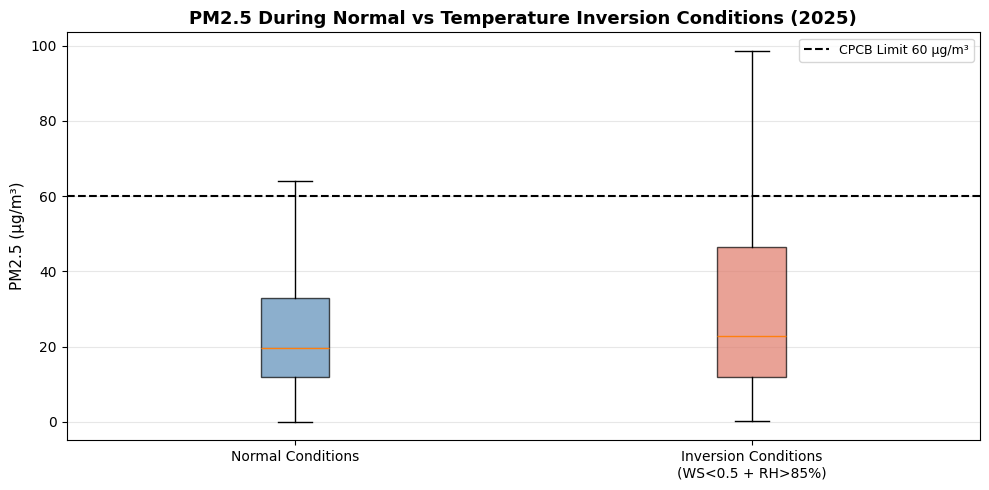

In [59]:
# Flag inversion nights
master_df['inversion'] = (
    (master_df['WS (m/s)'] < 0.5) &
    (master_df['RH (%)'] > 85)
)

inversion_pm25 = master_df[master_df['inversion'] == True]['PM2.5 (µg/m³)'].dropna()
normal_pm25    = master_df[master_df['inversion'] == False]['PM2.5 (µg/m³)'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot([normal_pm25, inversion_pm25],
                labels=['Normal Conditions', 'Inversion Conditions\n(WS<0.5 + RH>85%)'],
                patch_artist=True,
                showfliers=False)

bp['boxes'][0].set_facecolor('#5B8DB8')
bp['boxes'][1].set_facecolor('#E07B6A')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)

ax.axhline(y=60, color='black', linestyle='--',
           linewidth=1.5, label='CPCB Limit 60 µg/m³')

# Print key finding
inv_mean = inversion_pm25.mean()
nor_mean = normal_pm25.mean()
print(f"Normal conditions   avg PM2.5 : {nor_mean:.1f} µg/m³")
print(f"Inversion conditions avg PM2.5 : {inv_mean:.1f} µg/m³")
print(f"PM2.5 is {((inv_mean-nor_mean)/nor_mean*100):.1f}% higher during inversion")

ax.set_title('PM2.5 During Normal vs Temperature Inversion Conditions (2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section10_meteo/temperature_inversion.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Monsoon Rainfall Effect
## PM2.5 on rainy days vs non rainy days


C:\Users\pc\AppData\Local\Temp\ipykernel_13496\835731549.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([non_rainy_pm25, rainy_pm25],


Non rainy days avg PM2.5 : 27.7 µg/m³
Rainy days avg PM2.5     : 22.0 µg/m³
Rain reduces PM2.5 by    : 20.7%


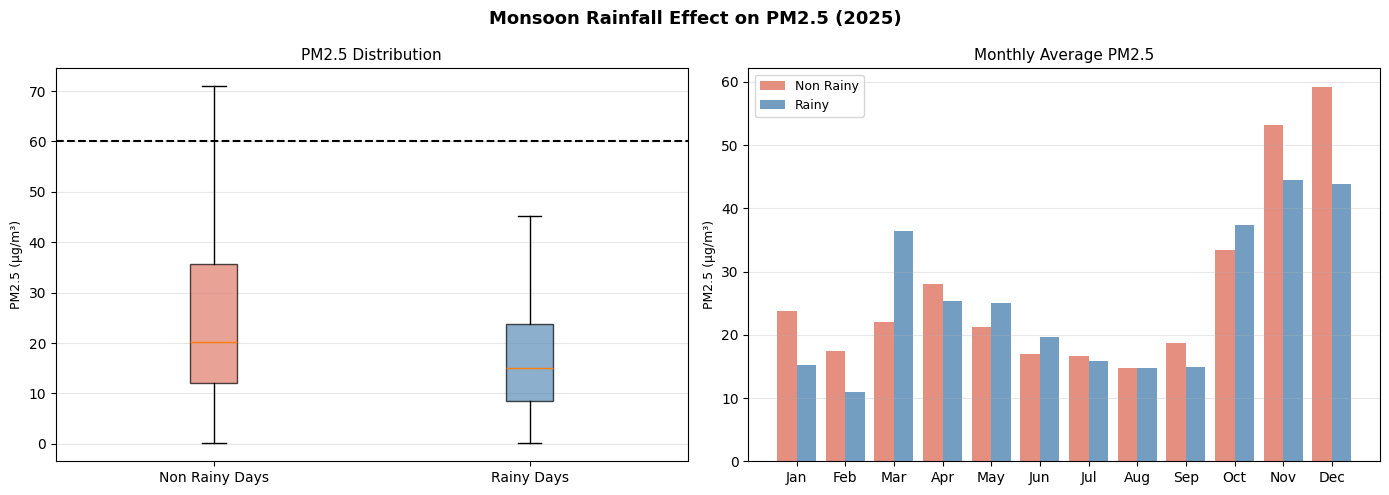

In [60]:
master_df['rainy'] = master_df['TOT-RF (mm)'] > 0

rainy_pm25    = master_df[master_df['rainy'] == True]['PM2.5 (µg/m³)'].dropna()
non_rainy_pm25 = master_df[master_df['rainy'] == False]['PM2.5 (µg/m³)'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monsoon Rainfall Effect on PM2.5 (2025)',
             fontsize=13, fontweight='bold')

# Box plot
bp = axes[0].boxplot([non_rainy_pm25, rainy_pm25],
                     labels=['Non Rainy Days', 'Rainy Days'],
                     patch_artist=True,
                     showfliers=False)
bp['boxes'][0].set_facecolor('#E07B6A')
bp['boxes'][1].set_facecolor('#5B8DB8')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
axes[0].axhline(y=60, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('PM2.5 Distribution', fontsize=11)
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart - monthly avg PM2.5 for rainy vs non rainy
monthly_rainy     = master_df[master_df['rainy'] == True].groupby('month')['PM2.5 (µg/m³)'].mean()
monthly_non_rainy = master_df[master_df['rainy'] == False].groupby('month')['PM2.5 (µg/m³)'].mean()

x = np.arange(1, 13)
axes[1].bar(x - 0.2, monthly_non_rainy.values, width=0.4,
            color='#E07B6A', label='Non Rainy', alpha=0.85)
axes[1].bar(x + 0.2, monthly_rainy.reindex(range(1,13)).fillna(0).values,
            width=0.4, color='#5B8DB8', label='Rainy', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].set_title('Monthly Average PM2.5', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Print key finding
print(f"Non rainy days avg PM2.5 : {non_rainy_pm25.mean():.1f} µg/m³")
print(f"Rainy days avg PM2.5     : {rainy_pm25.mean():.1f} µg/m³")
print(f"Rain reduces PM2.5 by    : {((non_rainy_pm25.mean()-rainy_pm25.mean())/non_rainy_pm25.mean()*100):.1f}%")

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section10_meteo/rainfall_effect.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Monsoon Rainfall Effect
## PM2.5 on rainy days vs non rainy days


C:\Users\pc\AppData\Local\Temp\ipykernel_13496\835731549.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([non_rainy_pm25, rainy_pm25],


Non rainy days avg PM2.5 : 27.7 µg/m³
Rainy days avg PM2.5     : 22.0 µg/m³
Rain reduces PM2.5 by    : 20.7%


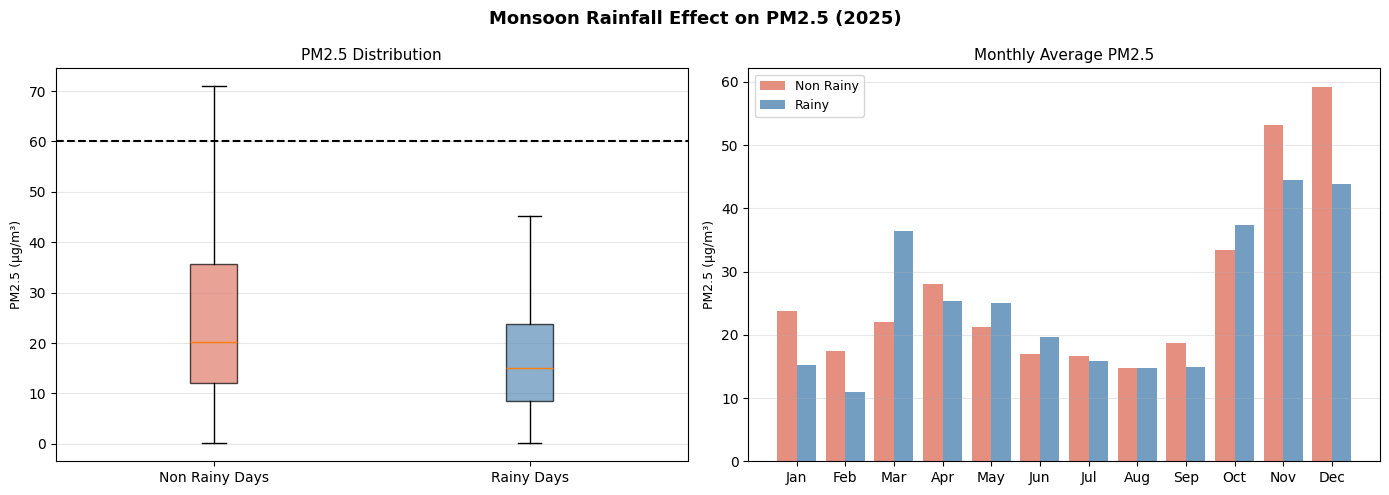

In [61]:
master_df['rainy'] = master_df['TOT-RF (mm)'] > 0

rainy_pm25    = master_df[master_df['rainy'] == True]['PM2.5 (µg/m³)'].dropna()
non_rainy_pm25 = master_df[master_df['rainy'] == False]['PM2.5 (µg/m³)'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monsoon Rainfall Effect on PM2.5 (2025)',
             fontsize=13, fontweight='bold')

# Box plot
bp = axes[0].boxplot([non_rainy_pm25, rainy_pm25],
                     labels=['Non Rainy Days', 'Rainy Days'],
                     patch_artist=True,
                     showfliers=False)
bp['boxes'][0].set_facecolor('#E07B6A')
bp['boxes'][1].set_facecolor('#5B8DB8')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
axes[0].axhline(y=60, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('PM2.5 Distribution', fontsize=11)
axes[0].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart - monthly avg PM2.5 for rainy vs non rainy
monthly_rainy     = master_df[master_df['rainy'] == True].groupby('month')['PM2.5 (µg/m³)'].mean()
monthly_non_rainy = master_df[master_df['rainy'] == False].groupby('month')['PM2.5 (µg/m³)'].mean()

x = np.arange(1, 13)
axes[1].bar(x - 0.2, monthly_non_rainy.values, width=0.4,
            color='#E07B6A', label='Non Rainy', alpha=0.85)
axes[1].bar(x + 0.2, monthly_rainy.reindex(range(1,13)).fillna(0).values,
            width=0.4, color='#5B8DB8', label='Rainy', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1].set_title('Monthly Average PM2.5', fontsize=11)
axes[1].set_ylabel('PM2.5 (µg/m³)', fontsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Print key finding
print(f"Non rainy days avg PM2.5 : {non_rainy_pm25.mean():.1f} µg/m³")
print(f"Rainy days avg PM2.5     : {rainy_pm25.mean():.1f} µg/m³")
print(f"Rain reduces PM2.5 by    : {((non_rainy_pm25.mean()-rainy_pm25.mean())/non_rainy_pm25.mean()*100):.1f}%")

plt.tight_layout()
plt.savefig('D:/varanasi_air_quality/outputs/charts/section10_meteo/rainfall_effect.png',
            dpi=150, bbox_inches='tight')
plt.show()